customer segmentation
----------------------------------------
segment summary:
          age    income  spending_score
segment                                
0        45.5  122689.5            72.2
1        54.5   76069.2            25.6
2        27.5   91701.2            24.9
3        38.8   42096.5            74.0


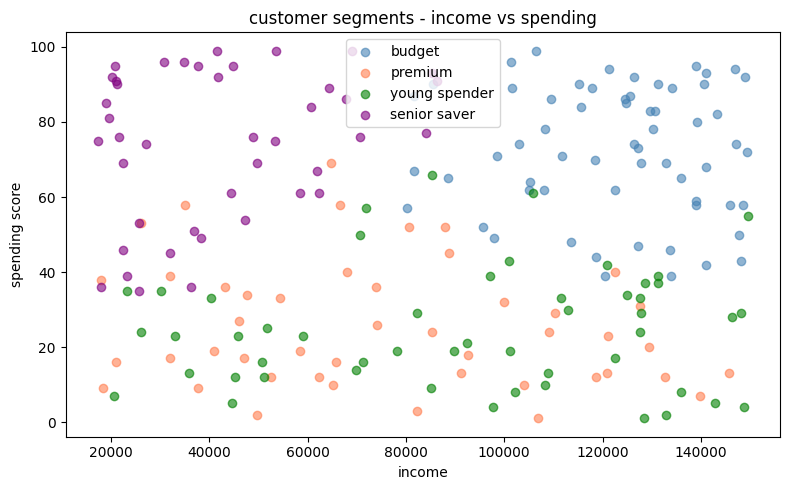

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

data = {
    "age":            np.random.randint(18, 65, n),
    "income":         np.random.randint(15000, 150000, n),
    "spending_score": np.random.randint(1, 100, n)
}

df = pd.DataFrame(data)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

model = KMeans(n_clusters=4, random_state=42, n_init=10)
df["segment"] = model.fit_predict(x_scaled)

print("customer segmentation")
print("-" * 40)
print("segment summary:")
print(df.groupby("segment")[["age", "income", "spending_score"]].mean().round(1))

colors = ["steelblue", "coral", "green", "purple"]
labels = ["budget", "premium", "young spender", "senior saver"]

plt.figure(figsize=(8, 5))
for i in range(4):
    cluster = df[df["segment"] == i]
    plt.scatter(cluster["income"], cluster["spending_score"],
                c=colors[i], label=labels[i], alpha=0.6)

plt.title("customer segments - income vs spending")
plt.xlabel("income")
plt.ylabel("spending score")
plt.legend()
plt.tight_layout()
plt.show()